# PDE Solver Validation

Comprehensive validation of the PDE solver against the Green's function approximation,
CosmoTherm, and literature values. Includes solver mode comparison and dark matter scenarios.

Merges content from: `pde_validation`, `test_pde_solver`

In [2]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure cargo is on PATH (rustup installs to ~/.cargo/bin, which
# Jupyter kernels may not inherit from the shell profile)
cargo_bin = Path.home() / ".cargo" / "bin"
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] = str(cargo_bin) + os.pathsep + os.environ.get("PATH", "")

from spectroxide import (
    run_sweep, solve, run_single,
    greens_function, mu_shape, y_shape, g_bb,
    j_mu, j_y, j_bb_star,
    KAPPA_C, BETA_MU,
    delta_n_to_delta_I,
    apply_style, C, SINGLE_COL, DOUBLE_COL,
)

# Publication style (Tol Vibrant palette, matching other notebooks)
apply_style()

FIG_DIR = Path("../../notebooks/figures")
FIG_DIR.mkdir(exist_ok=True)

# Run the full Rust PDE sweep (~60s)
print("Running PDE solver (cargo run --release) ...")
data = run_sweep(z_injections=np.geomspace(2e3, 3e6, 20), timeout=1000, production_grid=True)
print(f"Done. {len(data['results'])} injection redshifts.")

# Parse into arrays
results = data["results"]
delta_rho_inj = data["delta_rho_inj"]

z_h = np.array([r["z_h"] for r in results])
pde_mu = np.array([r["pde_mu"] for r in results])
gf_mu = np.array([r["gf_mu"] for r in results])
pde_y = np.array([r["pde_y"] for r in results])
gf_y = np.array([r["gf_y"] for r in results])
drho = np.array([r["drho"] for r in results])

# Downsampled spectra (list of arrays, one per z_h)
x_spectra = [np.array(r["x"]) for r in results]
dn_pde = [np.array(r["delta_n"]) for r in results]
dn_gf = [np.array(r["delta_n_gf"]) for r in results]

print(f"Injection: drho/rho = {delta_rho_inj:.1e}")
print(f"Redshift range: {z_h.min():.0e} -- {z_h.max():.0e}")

Running PDE solver (cargo run --release) ...


Done. 20 injection redshifts.
Injection: drho/rho = 1.0e-05
Redshift range: 2e+03 -- 3e+06


## Distortion Decomposition from PDE Spectra

The Rust solver extracts $\mu$, $y$, and $\Delta T/T$ internally using a hybrid
integral + least-squares method: $\Delta T/T$ is extracted analytically from the photon
number integral ($M$ and $Y_{\rm SZ}$ conserve number, so only $G_{\rm bb}$ contributes),
then $\mu$ and $y$ are fitted via 2-parameter least-squares on the number-conserving
residual $\Delta n_{\rm nc} = \Delta n - (\Delta T/T)\,G_{\rm bb}$. This eliminates
cross-talk from the temperature shift. These are the authoritative `pde_mu` and `pde_y`
values used throughout this notebook.

Below we also attempt a Python-side refit on the **downsampled spectra** (every 10th
grid point $\to$ ~30 points, cubic-spline interpolated to 1000 points). Because the
original grid is log-spaced at low $x$ where $M(x)$ and $Y_{\rm SZ}(x)$ diverge, the
downsampled grid cannot fully resolve the basis functions. The Python refit therefore
serves as a rough cross-check, not a precision measurement — differences vs the Rust
values are expected and dominated by this resolution effect.

In [3]:
from spectroxide import decompose_distortion
from scipy.interpolate import CubicSpline

# The sweep output contains downsampled spectra (every 10th grid point,
# ~30 points). For accurate spectral decomposition we interpolate onto a
# finer uniform grid (1000 points) covering the same x range.
N_INTERP = 1000

py_mu = np.zeros(len(z_h))
py_y = np.zeros(len(z_h))
py_dT = np.zeros(len(z_h))
py_drho = np.zeros(len(z_h))

for i in range(len(z_h)):
    x_ds = x_spectra[i]
    dn_ds = dn_pde[i]

    x_fine = np.linspace(x_ds.min(), x_ds.max(), N_INTERP)
    cs = CubicSpline(x_ds, dn_ds, extrapolate=False)
    dn_fine = cs(x_fine)
    dn_fine = np.nan_to_num(dn_fine, nan=0.0)

    d = decompose_distortion(x_fine, dn_fine)
    py_mu[i] = d["mu"]
    py_y[i] = d["y"]
    py_dT[i] = d["dT"]
    py_drho[i] = d["drho"]

# Print comparison table
header = (f"{'z_h':>10} {'Rust mu':>11} {'Py mu':>11} {'Py/Rust':>8} "
          f"{'Rust y':>11} {'Py y':>11} {'Py/Rust':>8} "
          f"{'Py dT/T':>11}")
print(header)
print("-" * len(header))
for i in range(len(z_h)):
    mu_rat = py_mu[i] / pde_mu[i] if abs(pde_mu[i]) > 1e-20 else float("nan")
    y_rat = py_y[i] / pde_y[i] if abs(pde_y[i]) > 1e-20 else float("nan")
    print(f"{z_h[i]:>10.0e} {pde_mu[i]:>11.3e} {py_mu[i]:>11.3e} {mu_rat:>8.3f} "
          f"{pde_y[i]:>11.3e} {py_y[i]:>11.3e} {y_rat:>8.3f} "
          f"{py_dT[i]:>11.3e}")

y_valid = np.abs(pde_y) > 1e-15
print(f"\nPython refit vs Rust PDE (interpolated to {N_INTERP}-point grid):")
print(f"  mu: median |Py/Rust| = {np.median(np.abs(py_mu / pde_mu)):.3f}")
print(f"  y:  median |Py/Rust| = {np.median(np.abs(py_y[y_valid] / pde_y[y_valid])):.3f}")

       z_h     Rust mu       Py mu  Py/Rust      Rust y        Py y  Py/Rust     Py dT/T
----------------------------------------------------------------------------------------
     2e+03   4.040e-09  -4.412e-08  -10.922   2.480e-06   2.505e-06    1.010   2.468e-08
     3e+03   1.387e-08  -3.408e-08   -2.458   2.486e-06   2.511e-06    1.010   2.354e-08
     4e+03   3.781e-08  -9.336e-09   -0.247   2.487e-06   2.512e-06    1.010   2.060e-08
     6e+03   9.629e-08   5.112e-08    0.531   2.488e-06   2.512e-06    1.010   1.345e-08
     9e+03   2.358e-07   1.955e-07    0.829   2.482e-06   2.505e-06    1.010  -3.509e-09
     1e+04   5.532e-07   5.238e-07    0.947   2.462e-06   2.485e-06    1.009  -4.116e-08
     2e+04   1.267e-06   1.261e-06    0.995   2.413e-06   2.433e-06    1.008  -1.214e-07
     3e+04   2.842e-06   2.884e-06    1.015   2.286e-06   2.300e-06    1.006  -2.805e-07
     4e+04   6.080e-06   6.201e-06    1.020   1.968e-06   1.972e-06    1.002  -5.482e-07
     6e+04   1.124e-0

## Figure 2: PDE vs GF Spectral Shapes

Full spectral distortion $\Delta n(x)$ from the PDE solver compared with the Green's function
at four representative redshifts spanning the $y$-era, transition, $\mu$-era, and near-thermalization
regime.

In [4]:
# Select 4 representative redshifts
z_targets = [3e3, 5e4, 3e5, 2e6]
labels_z = [r"$z_h = 3 \times 10^3$ ($y$-era)",
            r"$z_h = 5 \times 10^4$ (transition)",
            r"$z_h = 3 \times 10^5$ ($\mu$-era)",
            r"$z_h = 2 \times 10^6$ (near thermalization)"]

# Find closest indices in sweep data
idx_sel = [np.argmin(np.abs(z_h - zt)) for zt in z_targets]
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 5.0), sharex=True)
for ax, idx, label in zip(axes.flat, idx_sel, labels_z):
    x = x_spectra[idx]
    pde = dn_pde[idx]
    gf = dn_gf[idx]

    # Mask out very small x where numerical noise dominates
    mask = x > 0.01
    x_m, pde_m, gf_m = x[mask], pde[mask], gf[mask]

    # Plot Δn per unit Δρ/ρ vs dimensionless frequency x
    ax.plot(x_m, x_m**3 * pde_m / delta_rho_inj, color=C["blue"], lw=1.5, label="PDE")
    ax.plot(x_m, x_m**3 * gf_m / delta_rho_inj, color=C["red"], lw=1.0, ls="--", label="GF")
    ax.axhline(0, color="k", lw=0.3)
    ax.legend(fontsize=7, loc="best")
    ax.text(0.03, 0.93, label, transform=ax.transAxes, fontsize=7,
            va="top", ha="left")

for ax in axes[1, :]:
    ax.set_xlabel(r"$x$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\Delta n / (\Delta\rho/\rho)$")

fig.tight_layout()
fig.savefig(FIG_DIR / "pde_spectral_shapes.pdf")
plt.show()

/tmp/ipykernel_8903/2741285073.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Figure 3: Spectral Residual (PDE $-$ GF) / GF

Fractional difference between the PDE and Green's function spectra. The GF is an
approximation (Chluba 2013 fitting formulas), so $\sim 2$--$10\%$ residuals are expected,
especially near the $\mu$-$y$ transition and at the spectral zero crossings.

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 5.0), sharex=True)

for ax, idx, label in zip(axes.flat, idx_sel, labels_z):
    x = x_spectra[idx]
    pde = dn_pde[idx]
    gf = dn_gf[idx]

    mask = (x > 0.3) & (np.abs(gf) > 1e-15 * np.max(np.abs(gf)))
    x_m = x[mask]
    frac = (pde[mask] - gf[mask]) / gf[mask]

    ax.plot(x_m, frac * 100, color=C["blue"], lw=1.0)
    ax.axhline(0, color="k", lw=0.3)

    # Shade +/-10% band
    ax.axhspan(-10, 10, alpha=0.08, color=C["teal"])
    ax.set_title(label, fontsize=8)
    ax.set_ylim(-50, 50)

for ax in axes[1, :]:
    ax.set_xlabel(r"$x$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$(\mathrm{PDE} - \mathrm{GF}) / \mathrm{GF}$ [%]")

fig.suptitle("Fig. 3: Fractional spectral residual (PDE vs GF)", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "pde_spectral_residual.pdf")
plt.show()

/tmp/ipykernel_8903/1441182008.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Figure 4: Energy Conservation

The PDE solver should conserve the total photon energy:
$\Delta\rho/\rho$ (measured from the evolved spectrum) should match the injected
$\Delta\rho/\rho_{\rm inj}$. The ratio should be $\approx 1.0$ to within $\pm 5$--$10\%$.

In [6]:
energy_ratio = drho / delta_rho_inj
energy_pct = (energy_ratio - 1.0) * 100  # percentage deviation

fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.8))

# Plot in units of 10^{-5} %
ax.plot(z_h, energy_pct, "o-", ms=4, color=C["blue"], lw=0.8)
ax.axhline(0.0, color="k", lw=0.5, ls="-")

ax.set_xlabel(r"Injection redshift $z_h$")
ax.set_ylabel(r"Energy deviation [\%]")
ax.set_xscale("log")
ax.set_xlim(z_h.min() * 0.8, z_h.max() * 1.5)
# ax.set_ylim(-5, 5)

fig.savefig(FIG_DIR / "pde_energy_conservation.pdf")
plt.show()

print(f"Energy conservation: min deviation = {energy_pct.min():.4f}%, "
      f"max deviation = {energy_pct.max():.4f}%")
print(f"RMS deviation = {np.sqrt(np.mean(energy_pct**2)):.4f}%")
print(f"Max |deviation| = {np.abs(energy_pct).max():.4f}%")

Energy conservation: min deviation = -2.3690%, max deviation = -0.0822%
RMS deviation = 0.6246%
Max |deviation| = 2.3690%


/tmp/ipykernel_8903/2842821167.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Figure 5: $\mu$ and $y$ Relative Error (PDE vs GF)

Quantitative comparison of the integrated distortion parameters. The PDE solver extracts
$\mu$ and $y$ via weighted least-squares projection of $\Delta n(x)$ onto the spectral
basis $\{M(x), Y_{\rm SZ}(x), G(x)\}$. The GF uses Chluba's fitting formulas directly.

Expected tolerances from integration tests:
- $\mu$: $\lesssim 10\%$ relative error (where $\mu$ dominates)
- $y$: $\lesssim$ factor of 2 (where $y$ dominates)

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(DOUBLE_COL, 3.0))

# --- mu relative error ---
# Only plot where mu is significant (mu-era: z > ~3e4)
mu_mask = np.abs(gf_mu) > 1e-15
mu_relerr = (pde_mu[mu_mask] - gf_mu[mu_mask]) / gf_mu[mu_mask]

ax1.semilogx(z_h[mu_mask], mu_relerr * 100, "o-", ms=5, color=C["orange"], lw=1.0)
ax1.axhline(0, color="k", lw=0.3)

# 10% tolerance band
ax1.axhspan(-10, 10, alpha=0.10, color=C["teal"])
ax1.text(z_h[mu_mask].max() * 1.1, 10, r"$\pm 10\%$", fontsize=7,
         color=C["teal"], va="bottom")

ax1.set_xlabel(r"Injection redshift $z_h$")
ax1.set_ylabel(r"$(\mu_{\rm PDE} - \mu_{\rm GF}) / \mu_{\rm GF}$ [%]")
ax1.set_title(r"(a) $\mu$ relative error")
ax1.set_ylim(-100, 100)

# --- y relative error ---
# Only plot where y is significant (y-era: z < ~5e4)
y_mask = np.abs(gf_y) > 1e-15
y_relerr = (pde_y[y_mask] - gf_y[y_mask]) / gf_y[y_mask]

ax2.semilogx(z_h[y_mask], y_relerr * 100, "s-", ms=5, color=C["cyan"], lw=1.0)
ax2.axhline(0, color="k", lw=0.3)

# Factor-of-2 tolerance band
ax2.axhspan(-100, 100, alpha=0.08, color=C["teal"])
ax2.text(z_h[y_mask].max() * 1.1, 100, r"factor of 2", fontsize=7,
         color=C["teal"], va="bottom")

ax2.set_xlabel(r"Injection redshift $z_h$")
ax2.set_ylabel(r"$(y_{\rm PDE} - y_{\rm GF}) / y_{\rm GF}$ [%]")
ax2.set_title(r"(b) $y$ relative error")
ax2.set_ylim(-300, 300)

fig.suptitle("Fig. 5: PDE vs GF relative error in distortion parameters", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "pde_mu_y_error.pdf")
plt.show()

# Print summary
print(f"mu relative error: median = {np.median(np.abs(mu_relerr))*100:.1f}%, "
      f"max = {np.max(np.abs(mu_relerr))*100:.1f}%")
print(f"y  relative error: median = {np.median(np.abs(y_relerr))*100:.1f}%, "
      f"max = {np.max(np.abs(y_relerr))*100:.1f}%")

mu relative error: median = 17.2%, max = 83.6%
y  relative error: median = 10.2%, max = 628.1%


/tmp/ipykernel_8903/679297820.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Visibility Functions

The analytic visibility functions $\mathcal{J}_{\mathrm{bb}}^*$, $\mathcal{J}_\mu$, $\mathcal{J}_y$ from Chluba (2013).


In [8]:
# Combined visibility figure: analytic + PDE-derived visibility functions
# with color-coded thermalization eras.
#
# PDE visibility functions extracted via SPECTRAL FITTING (Chluba 2013
# convention): for each z_h, find (J_mu, J_bb*) minimising the
# x^3-weighted spectral residual between the 3-component GF ansatz and
# the NC-stripped PDE spectrum. J_y uses Chluba's independently fitted
# formula (not 1 - J_mu). This gives much cleaner results in the
# transition region than the energy-conserving mu/y decomposition.

from scipy.optimize import minimize as sp_minimize
from spectroxide.cosmotherm import strip_gbb

def _gf_model(x, j_mu_val, j_bb_star_val, j_y_val):
    """Three-component Green's function ansatz (per unit Drho/rho).
    
    Uses independently fitted J_y (Chluba 2013) instead of (1 - J_mu).
    T-shift fraction = 1 - J_mu*J_bb* - J_y (can go slightly negative).
    """
    return ((3.0 / KAPPA_C) * j_mu_val * j_bb_star_val * mu_shape(x)
            + 0.25 * j_y_val * y_shape(x)
            + 0.25 * (1.0 - j_mu_val * j_bb_star_val - j_y_val) * g_bb(x))

j_mu_pde = np.zeros(len(z_h))
j_bb_star_pde = np.zeros(len(z_h))

for i in range(len(z_h)):
    x_i = x_spectra[i]
    dn_i = dn_pde[i]

    # Restrict to x in [0.5, 20] for fitting
    mask = (x_i >= 0.5) & (x_i <= 20)
    x_fit = x_i[mask]
    dn_fit = dn_i[mask]
    dn_nc, _ = strip_gbb(x_fit, dn_fit)

    # J_y from Chluba's independent fit (fixed, not a free parameter)
    j_y_i = j_y(z_h[i])

    def _residual(params, j_y_fixed=j_y_i):
        jm, jb = params
        model = _gf_model(x_fit, jm, jb, j_y_fixed) * delta_rho_inj
        model_nc, _ = strip_gbb(x_fit, model)
        return np.sum((x_fit**3 * (model_nc - dn_nc))**2)

    res = sp_minimize(
        _residual,
        [j_mu(z_h[i]), j_bb_star(z_h[i])],
        bounds=[(0, 1), (0, 1)],
        method="L-BFGS-B",
    )
    j_mu_pde[i] = res.x[0]
    j_bb_star_pde[i] = res.x[1]

# J_y from Chluba's independent formula (NOT 1 - J_mu)
j_y_pde = j_y(z_h)

# --- Mask J_bb* to where J_mu is large enough for it to be constrained ---
mask_bb = (j_mu_pde > 0.5) & (z_h < 2e6)

z_vis = np.logspace(3, 7, 500)

fig, ax = plt.subplots(figsize=(SINGLE_COL, 3.2))

# Era shading
ax.axvspan(1e3, 5e4, alpha=0.06, color=C["teal"])
ax.axvspan(5e4, 2e5, alpha=0.06, color=C["purple"])
ax.axvspan(2e5, 2e6, alpha=0.06, color=C["orange"])
ax.axvspan(2e6, 1e7, alpha=0.06, color=C["blue"])

# Era labels
ax.text(8e3, 1.02, r"$y$-era", fontsize=7, color=C["teal"], ha="center")
ax.text(1e5, 1.02, "transition", fontsize=6, color=C["purple"], ha="center")
ax.text(6e5, 1.07, r"$\mu$-era", fontsize=7, color=C["orange"], ha="center")
ax.text(4e6, 0.7, "therm.", fontsize=7, color=C["blue"], ha="center")

# Analytic curves
ax.semilogx(z_vis, j_bb_star(z_vis), color=C["blue"], lw=1.5,
            label=r"$\mathcal{J}_{\mathrm{bb}}^*(z)$")
ax.semilogx(z_vis, j_mu(z_vis), color=C["orange"], lw=1.5,
            label=r"$\mathcal{J}_\mu(z)$")
ax.semilogx(z_vis, j_y(z_vis), color=C["teal"], lw=1.5, ls="--",
            label=r"$\mathcal{J}_y(z)$")

# PDE-derived points (spectral fit)
ax.plot(z_h, j_mu_pde, "o", ms=3.5, color=C["orange"], zorder=5, mfc="white", mew=1.0,
        label=r"$\mathcal{J}_\mu^{\rm PDE}$")
ax.plot(z_h, j_y_pde, "s", ms=3.5, color=C["teal"], zorder=5, mfc="white", mew=1.0,
        label=r"$\mathcal{J}_y^{\rm PDE}$")
ax.plot(z_h[mask_bb], j_bb_star_pde[mask_bb], "^", ms=3.5, color=C["blue"], zorder=5,
        mfc="white", mew=1.0, label=r"$\mathcal{J}_{\mathrm{bb}}^{*,\rm PDE}$")

# Era boundary lines
ax.axvline(5e4, color=C["gray"], ls=":", lw=0.5)
ax.axvline(2e5, color=C["gray"], ls=":", lw=0.5)
ax.axvline(2e6, color=C["gray"], ls=":", lw=0.5)

ax.set_xlabel(r"Redshift $z$")
ax.set_ylabel(r"Visibility function")
ax.set_xlim(1e3, 1e7)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=6.5, loc="center left", ncol=1)

fig.savefig(FIG_DIR / "visibility_functions_combined.pdf")
# Also save under old name for backward compat
fig.savefig(FIG_DIR / "lit_visibility_functions.pdf")
plt.show()

/tmp/ipykernel_8903/807510659.py:107: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Figure 9: PDE Solver --- FIRAS Limits on Photon Production at Multiple Redshifts

Reproduction of Fig. 9 from [Chluba (2015)](https://arxiv.org/abs/1506.06582) using the
**full PDE Boltzmann solver**: COBE/FIRAS constraints on monochromatic photon injection at
dimensionless frequency $x_i = h\nu_i / kT$ during the $\mu$-era.

**Multi-redshift comparison.** We run the PDE at three injection redshifts:
- $z = 3 \times 10^5$ (deep $\mu$-era: minimal thermalization)
- $z = 10^5$ ($\mu$-era: partial transition starting)
- $z = 5 \times 10^4$ ($\mu$-$y$ transition: significant y-component)

At lower $z$, more of the injected energy goes into y-type distortions rather than
$\mu$-type, and the FIRAS constraint on $|\mu|$ weakens accordingly.

**Physics.** Injecting $\Delta N_\gamma / N_\gamma$ photons at frequency $x_i$ changes both
energy and number. The chemical potential is:

$$\mu = \frac{3}{\kappa_c}\left(\frac{G_2}{G_3}\,x_i - \frac{4}{3}\right) \frac{\Delta N_\gamma}{N_\gamma}$$

The zero crossing at $x_{i,0} = 4G_3/(3G_2) \approx 3.60$ is a non-trivial prediction
that must emerge from the PDE dynamics at each injection redshift.

In [9]:
# Shared definitions for solver mode comparisons
# (originally in a cell that was removed)

delta_rho = 1e-5  # injection amplitude for single-burst sweeps

def _get(d, key, fallback_key=None):
    """Get a value from a result dict, trying key then fallback_key."""
    if key in d:
        return d[key]
    if fallback_key is not None and fallback_key in d:
        return d[fallback_key]
    raise KeyError(f"Neither {key!r} nor {fallback_key!r} found in dict")

# Solver modes: Standard vs Number-Conserving
modes = {
    "Standard": {},
    "NC": {"number_conserving": True},
}

colors = {"Standard": "C0", "NC": "C1"}
markers = {"Standard": "o", "NC": "s"}

# Will be populated by sweep cells; initialize empty for cells that .get() on it
all_results = {name: [] for name in modes}

In [10]:
# Focus on high-z where over-thermalization matters
high_z = [1e5, 2e5, 3e5, 5e5, 7e5, 1e6]

high_z_results = {}
for name, flags in modes.items():
    print(f"\n=== {name}: high-z sweep ===")
    sweep = run_sweep(
        delta_rho=delta_rho,
        z_injections=high_z,
        timeout=1800,
        **flags,
    )
    high_z_results[name] = sweep["results"]
    for r in sweep["results"]:
        zh = _get(r, "z_h", "z_injection")
        mu = _get(r, "pde_mu", "mu")
        drho_out = _get(r, "drho", "delta_rho_over_rho")
        print(f"  z_h={zh:.0e}  mu/drho={mu/delta_rho:.4f}  E_err={(drho_out/delta_rho-1)*100:.1f}%")


=== Standard: high-z sweep ===


  z_h=1e+05  mu/drho=1.5797  E_err=-0.1%
  z_h=2e+05  mu/drho=1.5077  E_err=-0.1%
  z_h=3e+05  mu/drho=1.4252  E_err=-0.1%
  z_h=5e+05  mu/drho=1.3667  E_err=-0.2%
  z_h=7e+05  mu/drho=1.3013  E_err=-0.2%
  z_h=1e+06  mu/drho=1.1589  E_err=-0.3%

=== NC: high-z sweep ===


  z_h=1e+05  mu/drho=1.5797  E_err=-0.1%
  z_h=2e+05  mu/drho=1.5077  E_err=-0.1%
  z_h=3e+05  mu/drho=1.4252  E_err=-0.1%
  z_h=5e+05  mu/drho=1.3667  E_err=-0.2%
  z_h=7e+05  mu/drho=1.3014  E_err=-0.2%
  z_h=1e+06  mu/drho=1.1593  E_err=-0.2%


### Solver Modes vs CosmoTherm (if database available)

In [11]:
from spectroxide.cosmotherm import (
    load_greens_database,
    convolve_cosmotherm_gf, strip_gbb,
    ct_heating_rate_swave, ct_heating_rate_pwave, ct_heating_rate_decay,
    cosmotherm_gf_distortion, reconstruct_full_gf,
    cosmotherm_gf_to_delta_n,
)
from spectroxide.greens import COSMOTHERM_GF_COSMO

In [12]:
try:
    z_h_ct, x_ct, g_th_ct = load_greens_database()
    has_cosmotherm = True
    print(f"CosmoTherm GF database loaded: {len(z_h_ct)} redshifts, {len(x_ct)} frequencies")
except FileNotFoundError:
    has_cosmotherm = False
    print("CosmoTherm GF database not found")

CosmoTherm GF database loaded: 118 redshifts, 4190 frequencies


### Paper Figure: PDE vs CosmoTherm Comparison

Generates `pde_cosmotherm_comparison.pdf` (Figure 1 in paper).

In [13]:
from spectroxide.plot_params import (
    LW, LW_THIN, LW_THICK, LW_AXIS,
    ANNOT_SIZE, RESID_BAND, RESID_BAND_ALPHA, RESID_MASK_FRAC,
)


In [ ]:
if has_cosmotherm:
    # Load with metadata for temperature shift reconstruction
    z_h_ct_m, x_ct_m, g_th_ct_m, meta = load_greens_database(include_metadata=True)
    g_th_full = reconstruct_full_gf(x_ct_m, g_th_ct_m, z_h_ct_m, meta, apply_exp=True)

    # 6 panels (2 rows x 3 cols): y-era through thermalization
    target_zh = [3e3, 1e4, 5e4, 2e5, 5e5, 2e6]
    era_labels = [
        r"$y$-era", r"$y$-era (late)", r"$y$--$\mu$ transition",
        r"$\mu$-era", r"$\mu$-era (deep)", "near thermalization",
    ]

    def _fmt_zh(z):
        """Format z_h as nice LaTeX scientific notation."""
        exp = int(np.floor(np.log10(z)))
        coeff = z / 10**exp
        if abs(coeff - 1.0) < 0.01:
            return rf"$z_h = 10^{exp}$"
        elif abs(coeff - round(coeff)) < 0.01:
            return rf"$z_h = {int(round(coeff))} \times 10^{exp}$"
        else:
            return rf"$z_h = {coeff:.1f} \times 10^{exp}$"

    ct_matches = []
    for zt in target_zh:
        idx = np.argmin(np.abs(z_h_ct_m - zt))
        ct_matches.append((z_h_ct_m[idx], idx))
    test_zh = [zh for zh, _ in ct_matches]
    ct_col_indices = [ci for _, ci in ct_matches]

    print("Matched CosmoTherm z_h values:")
    for zt, zh_exact, ci in zip(target_zh, test_zh, ct_col_indices):
        print(f"  Target {zt:.0e} -> CT z_h = {zh_exact:.2f} (col {ci})")

    # Run PDE at exact CT z_h values
    print("\nRunning PDE at matched z_h values...")
    pde_ct_results = {}
    low_z = [zh for zh in test_zh if zh < 1e6]
    high_z = [zh for zh in test_zh if zh >= 1e6]

    if low_z:
        sw_low = run_sweep(delta_rho=delta_rho, z_injections=low_z,
                           n_points=2000, production_grid=True, timeout=1200)
        for r in sw_low["results"]:
            zh_r = _get(r, "z_h", "z_injection")
            best = min(low_z, key=lambda z: abs(z - zh_r))
            pde_ct_results[best] = r

    for zh in high_z:
        print(f"  High-z PDE: z_h={zh:.1e}, n_points=4000")
        sw_hi = solve(delta_rho=delta_rho,
                      injection={"type": "single-burst", "z_h": zh},
                      z_start=max(zh * 2.5, 3e6), z_end=500,
                      n_points=4000, production_grid=True, timeout=1200)
        pde_ct_results[zh] = {"x": sw_hi.x.tolist(), "delta_n": sw_hi.delta_n.tolist(),
                              "pde_mu": sw_hi.mu, "pde_y": sw_hi.y,
                              "drho": sw_hi.delta_rho_over_rho, "z_h": sw_hi.z_h}

    x_query = np.linspace(0.3, 15, 400)


In [15]:
# ================================================================
# Paper Figure: PDE vs CosmoTherm comparison
# 2 rows x 3 cols, each with spectrum + residual
# Plots intensity Delta I_nu [Jy/sr] vs frequency nu [GHz]
# ================================================================
n_cols = 3
n_rows = 2
fig, all_axes = plt.subplots(
    n_rows * 2, n_cols,
    figsize=(DOUBLE_COL, 4.0),
    gridspec_kw={"height_ratios": [3, 1, 3, 1], "hspace": 0.05, "wspace": 0.30},
    sharex="col",
)

for i_panel, (zh, ct_col, era) in enumerate(zip(test_zh, ct_col_indices, era_labels)):
    row = i_panel // n_cols
    col = i_panel % n_cols
    ax = all_axes[row * 2, col]       # spectrum
    ax_b = all_axes[row * 2 + 1, col]  # residual

    # CosmoTherm: full (G_bb restored)
    gf_full = np.interp(x_query, x_ct_m, g_th_full[:, ct_col])
    dn_ct_full = cosmotherm_gf_to_delta_n(x_query, gf_full)

    # Analytical GF
    dn_gf = greens_function(x_query, zh)

    # PDE
    r_pde = pde_ct_results.get(zh)
    dn_pde = None
    if r_pde is not None:
        dn_pde = np.interp(x_query, np.array(r_pde["x"]),
                            np.array(r_pde["delta_n"]) / delta_rho)

    # Convert to intensity [Jy/sr] vs frequency [GHz]
    nu_ghz, di_ct = delta_n_to_delta_I(x_query, dn_ct_full)
    _, di_gf = delta_n_to_delta_I(x_query, dn_gf)
    di_pde = None
    if dn_pde is not None:
        _, di_pde = delta_n_to_delta_I(x_query, dn_pde)

    # --- Spectrum panel ---
    ax.plot(x_query, di_ct, color=C["black"], ls="-", lw=LW_THICK,
            label=r"CosmoTherm")
    ax.plot(x_query, di_gf, color=C["red"], ls="--", lw=LW,
            label="Analytical GF")
    if di_pde is not None:
        ax.plot(x_query, di_pde, color=C["blue"], ls="-", lw=LW,
                label=r"spectroxide PDE")
    ax.axhline(0, color=C["gray"], lw=LW_AXIS)
    ax.set_xscale("log")
    ax.text(0.03, 0.93, f"{era}\n{_fmt_zh(target_zh[i_panel])}",
            transform=ax.transAxes, va="top", ha="left", fontsize=ANNOT_SIZE)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))
    if col == 0:
        ax.set_ylabel(r"$\Delta I / (\Delta\rho/\rho)$ [Jy/sr]", fontsize=10)
    if i_panel == 0:
        ax.legend(fontsize=ANNOT_SIZE - 1, loc="center left")

    # --- Residual panel ---
    peak_ct = np.max(np.abs(dn_ct_full))
    # mask = np.abs(dn_ct_full) > RESID_MASK_FRAC * peak_ct

    pct_gf = np.full_like(dn_gf, np.nan)
    pct_gf = (dn_gf - dn_ct_full) / peak_ct * 100
    ax_b.plot(x_query, pct_gf, color=C["red"], ls="--", lw=LW_THIN,
                label=r"GF$-$CT")

    if dn_pde is not None:
        pct_pde = np.full_like(dn_pde, np.nan)
        pct_pde = (dn_pde - dn_ct_full) / peak_ct * 100
        ax_b.plot(x_query, pct_pde, color=C["blue"], lw=LW_THIN,
                    label=r"PDE$-$CT")
        rms = np.sqrt(np.nanmean(pct_pde**2))
        # ax_b.text(0.95, 0.05, f"{rms:.1f}%",
        #           transform=ax_b.transAxes, ha="right", va="bottom",
        #           fontsize=ANNOT_SIZE, color=C["blue"])

    ax_b.axhline(0, color=C["black"], lw=LW_AXIS)
    ax_b.set_xscale("log")
    ax_b.set_ylim(-5, 5)
    if row == 1:
        ax_b.set_xlabel(r"$x$")
    if col == 0:
        ax_b.set_ylabel(r"[$\%$]", fontsize=8)
    if i_panel == 0:
        ax_b.legend(fontsize=ANNOT_SIZE - 1, loc="center right")

plt.savefig("../../notebooks/figures/pde_cosmotherm_comparison.pdf", bbox_inches="tight")
plt.show()

# RMS error table
print(f"\n--- CosmoTherm comparison RMS errors ---")
print(f"{'z_h':>12s}  {'Era':>20s}  {'RMS%':>8s}")
print("-" * 50)
for zh, ct_col, era in zip(test_zh, ct_col_indices, era_labels):
    gf_full = np.interp(x_query, x_ct_m, g_th_full[:, ct_col])
    dn_ct_f = cosmotherm_gf_to_delta_n(x_query, gf_full)
    peak_ct = np.max(np.abs(dn_ct_f))
    mask = np.abs(dn_ct_f) > RESID_MASK_FRAC * peak_ct
    r_pde = pde_ct_results.get(zh)
    if r_pde is not None:
        dn_p = np.interp(x_query, np.array(r_pde["x"]),
                            np.array(r_pde["delta_n"]) / delta_rho)
        rms = np.sqrt(np.nanmean(((dn_p - dn_ct_f) / peak_ct * 100)**2))
        print(f"{zh:12.2f}  {era:>20s}  {rms:7.1f}%")



--- CosmoTherm comparison RMS errors ---
         z_h                   Era      RMS%
--------------------------------------------------
     2931.14               $y$-era      0.2%
    10018.26        $y$-era (late)      0.0%
    49581.63  $y$--$\mu$ transition      0.0%
   201687.62             $\mu$-era      0.0%
   500000.00      $\mu$-era (deep)      0.0%
  1944077.59   near thermalization      0.2%


/tmp/ipykernel_8903/3224188296.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---

## High-Redshift Thermalization ($z$ up to $10^7$)

At high redshifts, $J_{bb}^*$ grows and most injected energy is thermalized.
The PDE should show progressively smaller distortions. Uses production grid
(4000 points) for $z \geq 10^6$.

In [ ]:
# High-redshift PDE runs from y-era to deep thermalization
# At high redshifts, J_bb* grows => most energy is thermalized
# The PDE should show progressively smaller distortions
#
# Use production grid (4000 points) for z >= 1e6 where DC/BR
# stiffness at low x requires finer resolution. The default
# 1000-point grid under-resolves the 1/x³ emission at these
# redshifts, causing ~2× overshoot in mu/drho.

high_z_values = [7e5, 1e6, 2e6, 5e6]
high_z_results = {}

for zh in high_z_values:
    z_start = max(zh * 3.0, 3e6)
    # Use production grid (4000 pts) for z >= 1e6
    npts = 4000 if zh >= 1e6 else None
    grid_label = f", n_points={npts}" if npts else ""
    print(f"Running PDE at z_h = {zh:.0e} (z_start = {z_start:.0e}{grid_label})...")
    sweep_hz = solve(
        delta_rho=1e-5,
        injection={"type": "single-burst", "z_h": zh},
        z_start=z_start,
        z_end=500,
        n_points=npts,
        timeout=1200,
    )
    r = {"x": sweep_hz.x.tolist(), "delta_n": sweep_hz.delta_n.tolist(),
         "pde_mu": sweep_hz.mu, "pde_y": sweep_hz.y,
         "drho": sweep_hz.delta_rho_over_rho, "z_h": sweep_hz.z_h}
    high_z_results[zh] = r
    mu_hz = _get(r, "pde_mu", "mu")
    y_hz = _get(r, "pde_y", "y")
    drho_hz = _get(r, "drho", "delta_rho_over_rho")
    jbb = j_bb_star(zh)
    print(f"  J_bb*({zh:.0e}) = {jbb:.4f}")
    print(f"  PDE:  mu = {mu_hz:.3e}, y = {y_hz:.3e}, drho = {drho_hz:.3e}")
    
    # GF prediction
    gf_hz = run_single(z_h=zh, delta_rho=delta_rho)
    mu_gf = gf_hz["mu"]
    mu_target = 1.401 * jbb * j_mu(zh) * delta_rho
    print(f"  GF:   mu = {mu_gf:.3e}, y = {gf_hz['y']:.3e}")
    print(f"  GF target: mu/drho = 1.401 × J_bb* × J_mu = {mu_target/delta_rho:.4f}")
    if abs(mu_gf) > 1e-20:
        print(f"  PDE/GF ratio: {mu_hz / mu_gf:.3f}")
    print()

# --- Plot: spectral shapes at high z ---
n_hz = len(high_z_values)
fig, axes = plt.subplots(2, n_hz, figsize=(4*n_hz, 8),
                          gridspec_kw={"height_ratios": [3, 1]})

for idx, zh in enumerate(high_z_values):
    r = high_z_results[zh]
    x_hz = np.array(r["x"])
    dn_hz = np.array(r["delta_n"])
    dn_gf = greens_function(x_hz, zh) * delta_rho

    nu_hz, di_pde = delta_n_to_delta_I(x_hz, dn_hz)
    _, di_gf = delta_n_to_delta_I(x_hz, dn_gf)

    ax = axes[0, idx]
    ax.plot(nu_hz, di_pde, "b-", lw=1.5, label="PDE")
    ax.plot(nu_hz, di_gf, "r--", lw=1.5, label="GF")
    ax.axhline(0, color="k", lw=0.5)
    jbb = j_bb_star(zh)
    npts = 4000 if zh >= 1e6 else 1000
    ax.set_title(f"$z_h = {zh:.0e}$\n$J_{{bb}}^* = {jbb:.4f}$, N={npts}", fontsize=11)
    ax.set_xscale("log")
    if idx == 0:
        ax.set_ylabel(r"$\Delta I_\nu$ [Jy/sr]")
        ax.legend(fontsize=8)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

    # Percent deviation
    ax = axes[1, idx]
    peak = np.max(np.abs(dn_gf))
    if peak > 1e-30:
        mask = np.abs(dn_gf) > 0.05 * peak
        pct = np.full_like(dn_hz, np.nan)
        pct[mask] = (dn_hz[mask] / dn_gf[mask] - 1.0) * 100
        ax.plot(nu_hz, pct, "k-", lw=1)
    ax.axhline(0, color="k", lw=0.5)
    ax.axhspan(-10, 10, color="green", alpha=0.1)
    ax.set_xscale("log")
    ax.set_ylim(-50, 50)
    ax.set_xlabel(r"$\nu$ [GHz]")
    if idx == 0:
        ax.set_ylabel("PDE/GF - 1 [%]")

fig.suptitle(r"High-$z$ Thermalization: PDE vs GF ($\Delta\rho/\rho = 10^{-5}$, production grid for $z \geq 10^6$)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Tests ---
# mu should decrease with increasing z (more thermalization)
mu_values_hz = []
for zh in high_z_values:
    r = high_z_results[zh]
    mu_values_hz.append(abs(_get(r, "pde_mu", "mu")))

decreasing = all(mu_values_hz[i] >= mu_values_hz[i+1] for i in range(len(mu_values_hz)-1))
print(f"mu decreasing with z (more thermalization): {decreasing}")
for zh, mu_v in zip(high_z_values, mu_values_hz):
    gf_hz = run_single(z_h=zh, delta_rho=delta_rho)
    mu_gf = abs(gf_hz["mu"])
    ratio = mu_v / mu_gf if mu_gf > 1e-20 else float("nan")
    print(f"  z_h={zh:.0e}: |mu| = {mu_v:.3e}, J_bb* = {j_bb_star(zh):.4f}, PDE/GF = {ratio:.3f}")

results.append(("High-z: mu decreasing", decreasing,
                f"|mu| = {[f'{m:.1e}' for m in mu_values_hz]}"))

---

## Dark Matter Spectral Distortions --- CosmoTherm Calibration

Compare PDE solver results for continuous DM injection scenarios against
CosmoTherm Green's function convolution. Tests s-wave annihilation,
p-wave annihilation, and decaying particle.

In [17]:
from spectroxide import (
    hubble, n_hydrogen, rho_gamma, cosmic_time,
    DEFAULT_COSMO,
)
from spectroxide.greens import COSMOTHERM_GF_COSMO
from spectroxide.cosmotherm import (
    load_greens_database,
    convolve_cosmotherm_gf, strip_gbb,
    ct_heating_rate_swave, ct_heating_rate_pwave, ct_heating_rate_decay,
)

EV_SI = 1.602_176_634e-19  # J per eV

# Constants for x -> nu conversion
_K_B = 1.380_649e-23       # J/K
_H_PL = 6.626_070_15e-34   # J*s
_T_CMB = 2.726             # K

# ====================================================================
# 1. Parameter conversion: CosmoTherm -> our code
# ====================================================================
# CosmoTherm (Greens.cpp:430) heating function ALREADY includes g_heat
# internally. Our Rust PDE solver also includes g_heat in its heating
# rate formulas. So the conversion does NOT multiply by g_heat.
#
# Matching: f_ann_ours = f_ann_CT / n_H,0
# For decay: f_X_ours = f_X_CT (no conversion needed)

cosmo_gf = DEFAULT_COSMO

n_H_0 = n_hydrogen(0, cosmo_gf)
conv = 1.0 / n_H_0   # pure unit conversion, no g_heat

print(f"n_H,0 = {n_H_0:.4f} m^-3")
print(f"Conversion factor 1/n_H,0 = {conv:.2f} m^3")

# --- CosmoTherm fiducial parameters (from Greens.v1.0.3/python/) ---
f_ann_CT_sw = 1e-22                # s-wave [eV/s]
f_ann_sw = f_ann_CT_sw * conv

f_ann_CT_pw = 1e-26                # p-wave [eV/s]
f_ann_pw = f_ann_CT_pw * conv

z_X = 5e4                          # Decay redshift
f_over_zX = 5.0
f_X_CT = f_over_zX * z_X           # 2.5e5 eV
gamma_x = 1.0 / cosmic_time(z_X + 10, cosmo_gf)
f_X_decay = f_X_CT                 # no g_heat factor needed

print(f"\nConverted parameters:")
print(f"  s-wave: f_ann_CT = {f_ann_CT_sw:.0e} eV/s  ->  f_ann = {f_ann_sw:.3e} eV*m^3/s")
print(f"  p-wave: f_ann_CT = {f_ann_CT_pw:.0e} eV/s  ->  f_ann = {f_ann_pw:.3e} eV*m^3/s")
print(f"  Decay:  z_X = {z_X:.0e}, f_X = {f_X_CT:.0e} eV  ->  Gamma_X = {gamma_x:.3e}/s, "
      f"f_X = {f_X_decay:.0f} eV")

# ====================================================================
# 2. Run PDE solver with matched integration range

n_H,0 = 0.1893 m^-3
Conversion factor 1/n_H,0 = 5.28 m^3

Converted parameters:
  s-wave: f_ann_CT = 1e-22 eV/s  ->  f_ann = 5.283e-22 eV*m^3/s
  p-wave: f_ann_CT = 1e-26 eV/s  ->  f_ann = 5.283e-26 eV*m^3/s
  Decay:  z_X = 5e+04, f_X = 2e+05 eV  ->  Gamma_X = 1.072e-10/s, f_X = 250000 eV


In [ ]:
# ====================================================================
# CosmoTherm integrates from z_e=1001 to z_s~5e6 (Greens.cpp:59).
# Match z_end=1001 to avoid extra low-z y-type heating that CosmoTherm
# doesn't include. z_start=3e6 is close to CosmoTherm's effective
# upper limit (damping = 0.06 at z=3e6).
Z_START_DM = 3e6
Z_END_DM = 1001    # Match CosmoTherm's ze_G = 1.001e3
N_POINTS_DM = 4000  # 2000 for continuous DM scenarios

dm_scenarios = {
    "s-wave": {
        "injection": {"type": "annihilating_dm", "f_ann": f_ann_sw},
        "color": "C1", "ls": "--",
        "label": r"s-wave ($f_{\rm ann}^{\rm CT}=10^{-22}$ eV/s)",
    },
    "p-wave": {
        "injection": {"type": "annihilating_dm_pwave", "f_ann": f_ann_pw},
        "color": "C2", "ls": "-.",
        "label": r"p-wave ($f_{\rm ann}^{\rm CT}=10^{-26}$ eV/s)",
    },
    "Decay": {
        "injection": {"type": "decaying_particle",
                      "f_x": f_X_decay, "gamma_x": gamma_x},
        "color": "C0", "ls": "-",
        "label": r"Decay ($z_X=5\times10^4$, $f_X/z_X=5$ eV)",
    },
}

dm_results = {}
for name, cfg in dm_scenarios.items():
    print(f"\nRunning PDE: {name} (n_points={N_POINTS_DM}, "
          f"z={Z_START_DM:.0e}->{Z_END_DM})...")
    sw = solve(
        injection=cfg["injection"],
        delta_rho=1e-5,
        z_start=Z_START_DM,
        z_end=Z_END_DM,
        n_points=N_POINTS_DM,
        production_grid=True,
        timeout=1200,
    )
    r = {"x": sw.x.tolist(), "delta_n": sw.delta_n.tolist(),
         "pde_mu": sw.mu, "pde_y": sw.y,
         "drho": sw.delta_rho_over_rho, "z_h": sw.z_h}
    dm_results[name] = r
    mu_v = _get(r, "pde_mu", "mu")
    y_v = _get(r, "pde_y", "y")
    drho_v = _get(r, "drho", "delta_rho_over_rho")
    print(f"  mu = {mu_v:.3e},  y = {y_v:.3e},  Drho/rho = {drho_v:.3e}")

# ====================================================================
# 3. Python GF convolution (replaces SWIG bindings)
# ====================================================================

In [19]:
# Load CosmoTherm GF database and convolve with heating rates using
# our pure-Python implementation.
z_h_ct, x_ct, g_th_ct = load_greens_database()

ct_heating_funcs = {
    "s-wave": lambda z: ct_heating_rate_swave(z, f_ann_CT_sw),
    "p-wave": lambda z: ct_heating_rate_pwave(z, f_ann_CT_pw),
    "Decay":  lambda z: ct_heating_rate_decay(z, f_X_CT, gamma_x),
}

ct_distortions = {}
print(f"\nPython GF convolution: {len(x_ct)} freq bins, "
      f"z = {Z_END_DM} -> {Z_START_DM:.0e}")

for name, dq_func in ct_heating_funcs.items():
    x_conv, di_conv = convolve_cosmotherm_gf(
        z_h_ct, x_ct, g_th_ct, dq_func,
        z_min=Z_END_DM, z_max=Z_START_DM, n_z=2000,
    )
    # Convert x to nu_ghz for plotting
    nu_conv = x_conv * _K_B * _T_CMB / _H_PL / 1e9
    ct_distortions[name] = (nu_conv, di_conv)
    print(f"  {name}: peak |DI| = {np.max(np.abs(di_conv)):.4e} Jy/sr")

# ====================================================================
# 3b. CosmoTherm SWIG cross-check (optional)
# ====================================================================
ct_swig_distortions = {}
has_ct_swig = False

try:
    import sys, pathlib
    _ct_py_dir = str(pathlib.Path("../../data/cosmotherm/Greens.v1.0.3/python").resolve())
    if _ct_py_dir not in sys.path:
        sys.path.insert(0, _ct_py_dir)
    import Greens as CT_GF

    CT_GF.set_verbosity(0)
    CT_NU_MIN, CT_NU_MAX, CT_DNU = 10.0, 1100.0, 1.0
    ct_nfreq = CT_GF.initialize_Greens_function(CT_NU_MIN, CT_NU_MAX, CT_DNU)
    nu_ct_swig = np.array([CT_NU_MIN + i * CT_DNU for i in range(ct_nfreq)])

    ct_params = {
        "s-wave": (f_ann_CT_sw, 0, 0, 0, 0, 0, 0, 0),
        "p-wave": (f_ann_CT_pw, 1, 0, 0, 0, 0, 0, 0),
        "Decay":  (0, 0, 0, 0, 0, 0, z_X, f_X_CT),
    }

    print(f"\nCosmoTherm SWIG cross-check: {ct_nfreq} freq bins, "
          f"nu = {CT_NU_MIN}-{CT_NU_MAX} GHz")

    for name, (f_a, wave, A, k0, nS, nrun, Gam, fX) in ct_params.items():
        Sig = np.ones(ct_nfreq)
        CT_GF.compute_mock_data_binned(Sig, f_a, wave, A, k0, nS, nrun,
                                       Gam, fX, 0.0, 0.0, 0.0)
        ct_swig_distortions[name] = (nu_ct_swig, Sig)
        print(f"  {name}: peak |DI| = {np.max(np.abs(Sig)):.4e} Jy/sr")

    has_ct_swig = True

except (ImportError, OSError) as e:
    print(f"\nCosmoTherm SWIG bindings not available: {e}")
    print("(Using Python GF convolution as primary comparison)")

# ====================================================================
# 4. Strip unobservable temperature shift from PDE spectra


Python GF convolution: 4190 freq bins, z = 1001 -> 3e+06


  s-wave: peak |DI| = 9.4300e+00 Jy/sr


  p-wave: peak |DI| = 2.4423e+02 Jy/sr


  Decay: peak |DI| = 1.5112e+03 Jy/sr


 s-wave: DT/T = +5.932e-10
 p-wave: DT/T = +1.127e-07
  Decay: DT/T = +5.345e-10


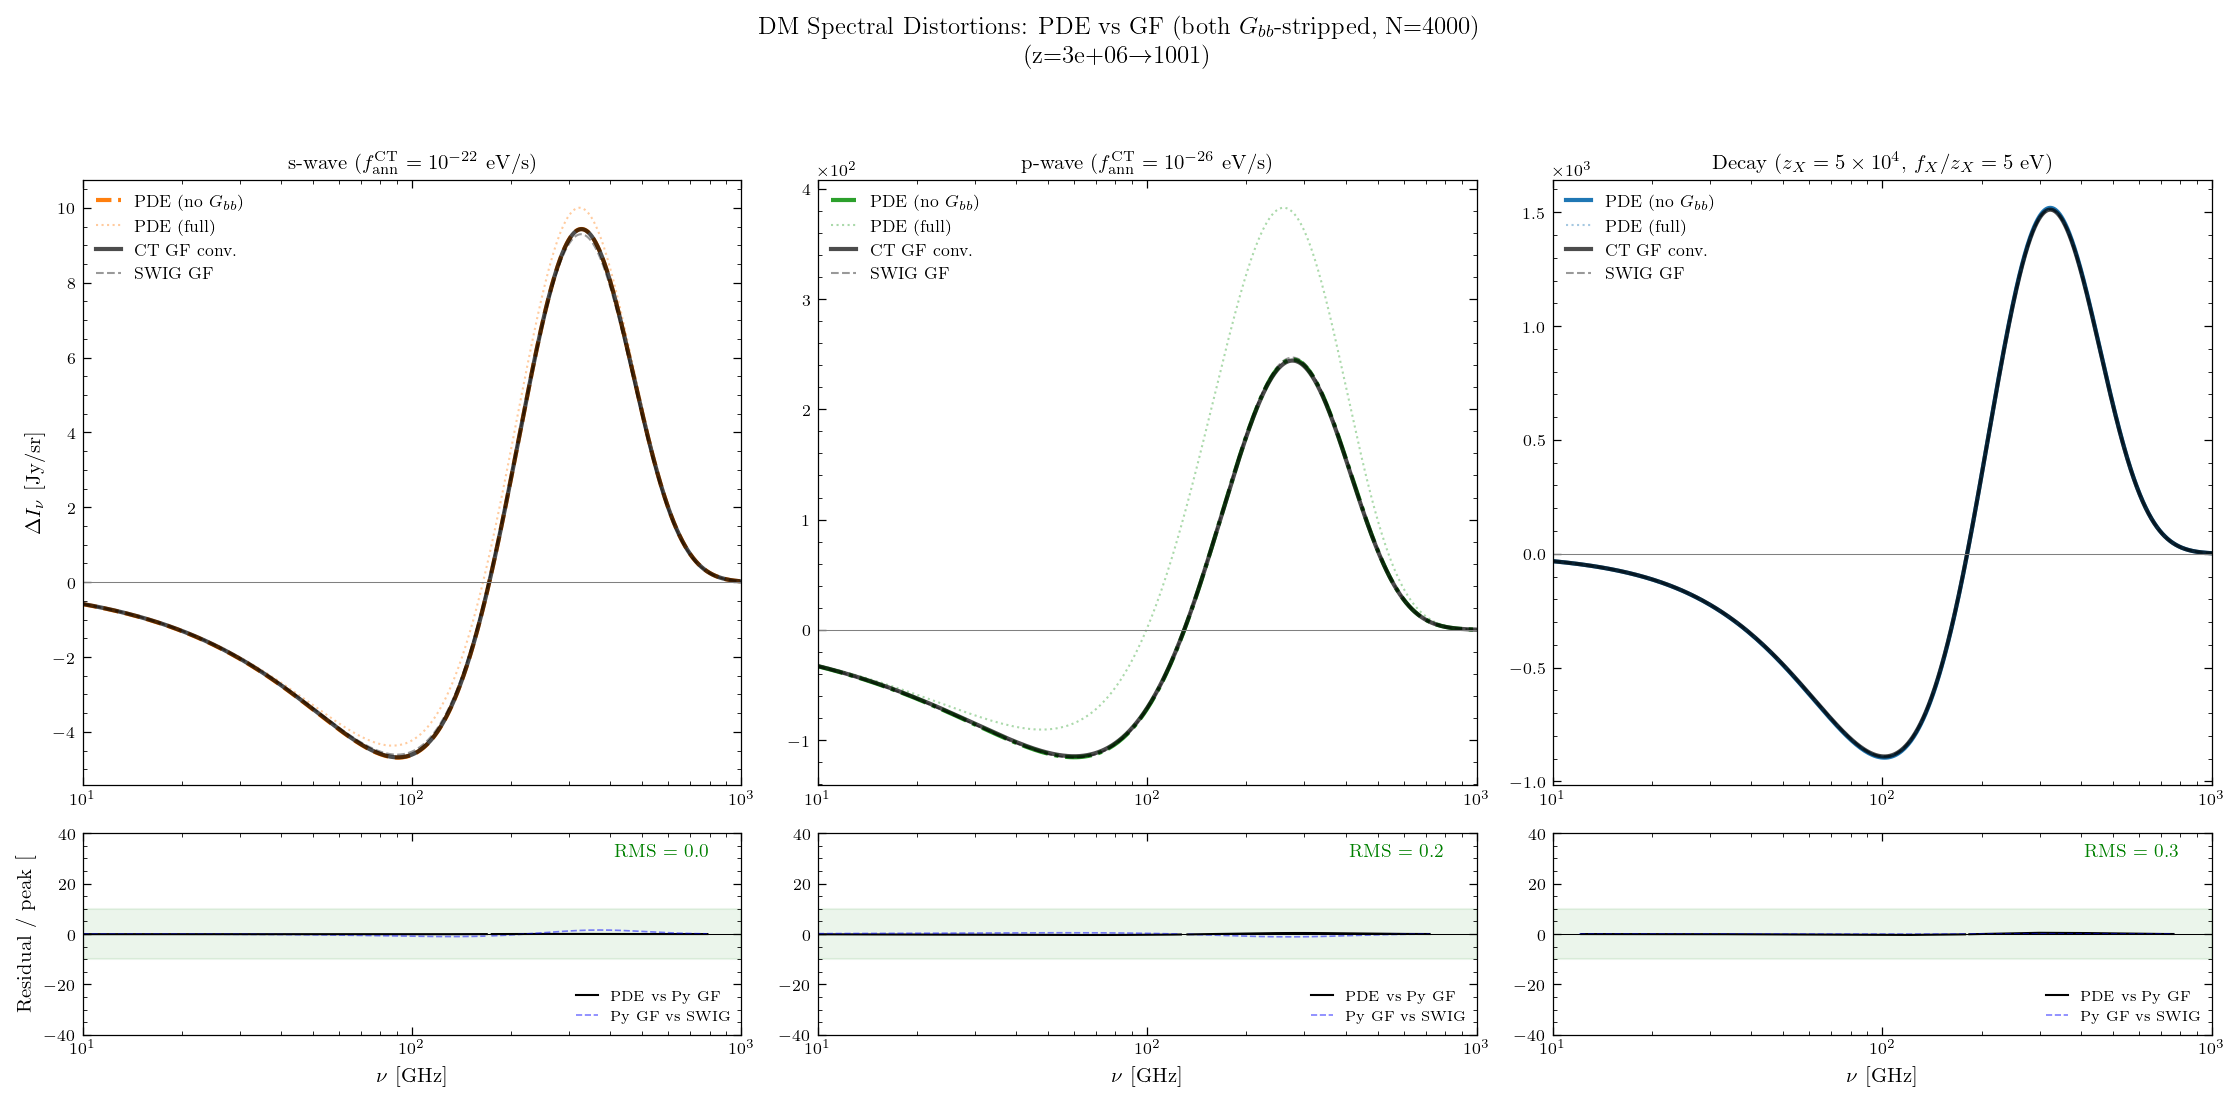

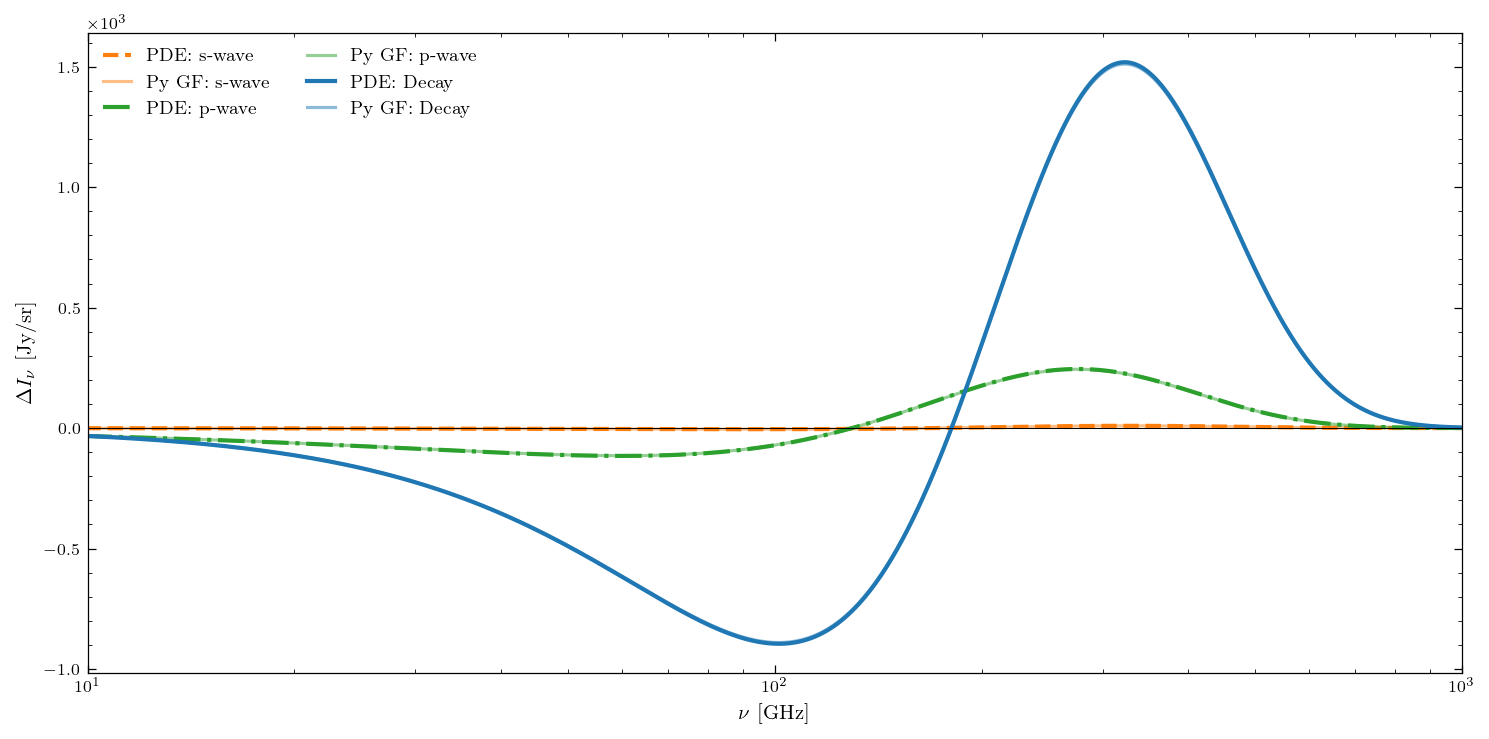


Scenario         mu_PDE      y_PDE   Drho/rho     mu/y
-------------------------------------------------------
s-wave        1.807e-08  2.900e-09  2.483e-08     6.23
p-wave        8.249e-07  5.973e-09  1.035e-06   138.10
Decay         2.512e-06  5.440e-07  3.239e-06     4.62

mu/y ratio: s-wave = 6.23,  p-wave = 138.10
p-wave has larger mu/y ratio (more high-z injection): True


In [19]:
# ====================================================================
# FIRAS measures with T as a free parameter, so DT/T is unobservable.
# CosmoTherm defines the distortion as the number-conserving part:
# int x^2 Dn dx = 0 (Chluba & Sunyaev 2012). This projection is
# orthogonal to mu and y (both conserve photon number). The CT GF
# database stores number-conserving entries by construction.

dm_results_no_gbb = {}
for name in dm_scenarios:
    r = dm_results[name]
    x_pde = np.array(r["x"])
    dn_pde = np.array(r["delta_n"])
    dn_stripped, alpha = strip_gbb(x_pde, dn_pde)
    dm_results_no_gbb[name] = (x_pde, dn_stripped)
    print(f"{name:>7s}: DT/T = {alpha:+.3e}")

# ====================================================================
# 5. Plot: PDE (G_bb subtracted) vs Python GF convolution
# ====================================================================
n_scen = len(dm_scenarios)
fig, axes = plt.subplots(2, n_scen, figsize=(5 * n_scen, 7),
                         gridspec_kw={"height_ratios": [3, 1]}, sharey=False)

for idx, (name, cfg) in enumerate(dm_scenarios.items()):
    ax = axes[0, idx]

    # PDE distortion-only (G_bb subtracted)
    x_pde, dn_no_gbb = dm_results_no_gbb[name]
    nu_pde, di_pde = delta_n_to_delta_I(x_pde, dn_no_gbb)
    ax.plot(nu_pde, di_pde, color=cfg["color"], ls=cfg["ls"], lw=2,
            label="PDE (no $G_{bb}$)")

    # Full PDE for reference
    r = dm_results[name]
    dn_full = np.array(r["delta_n"])
    _, di_full = delta_n_to_delta_I(x_pde, dn_full)
    ax.plot(nu_pde, di_full, color=cfg["color"], ls=":", lw=1, alpha=0.4,
            label="PDE (full)")

    # Python GF convolution (G_bb stripped)
    if name in ct_distortions:
        nu_c, di_c = ct_distortions[name]
        ax.plot(nu_c, di_c, "k-", lw=2, alpha=0.7, label="CT GF conv.")

    # SWIG cross-check
    if name in ct_swig_distortions:
        nu_s, di_s = ct_swig_distortions[name]
        ax.plot(nu_s, di_s, "k--", lw=1, alpha=0.4, label="SWIG GF")

    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xscale("log")
    ax.set_xlim(10, 1000)
    if idx == 0:
        ax.set_ylabel(r"$\Delta I_\nu$ [Jy/sr]")
    ax.set_title(cfg["label"], fontsize=10)
    ax.legend(fontsize=8)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

    # Bottom: percent deviation (G_bb-subtracted PDE vs Python GF)
    ax_b = axes[1, idx]
    if name in ct_distortions:
        nu_c, di_c = ct_distortions[name]
        di_pde_interp = np.interp(nu_c, nu_pde, di_pde)
        peak_ct = np.max(np.abs(di_c))
        mask = np.abs(di_c) > 0.03 * peak_ct
        pct = np.full_like(di_c, np.nan)
        pct[mask] = (di_pde_interp[mask] - di_c[mask]) / peak_ct * 100
        ax_b.plot(nu_c, pct, "k-", lw=1, label="PDE vs Py GF")
        rms = np.sqrt(np.nanmean(pct[mask]**2))
        ax_b.text(0.95, 0.95, f"RMS = {rms:.1f}%", transform=ax_b.transAxes,
                  ha="right", va="top", fontsize=9,
                  color="green" if rms < 10 else "red")

        # SWIG cross-check residual
        if name in ct_swig_distortions:
            nu_s, di_s = ct_swig_distortions[name]
            di_c_interp_s = np.interp(nu_s, nu_c, di_c)
            peak_s = np.max(np.abs(di_s))
            mask_s = np.abs(di_s) > 0.03 * peak_s
            pct_s = np.full_like(di_s, np.nan)
            pct_s[mask_s] = (di_c_interp_s[mask_s] - di_s[mask_s]) / peak_s * 100
            ax_b.plot(nu_s, pct_s, "b--", lw=0.8, alpha=0.5, label="Py GF vs SWIG")

    ax_b.axhline(0, color="k", lw=0.5)
    ax_b.axhspan(-10, 10, color="green", alpha=0.08)
    ax_b.set_xscale("log")
    ax_b.set_xlim(10, 1000)
    ax_b.set_ylim(-40, 40)
    ax_b.set_xlabel(r"$\nu$ [GHz]")
    if idx == 0:
        ax_b.set_ylabel("Residual / peak [%]")
    ax_b.legend(fontsize=7, loc="lower right")

fig.suptitle(f"DM Spectral Distortions: PDE vs GF (both $G_{{bb}}$-stripped, N={N_POINTS_DM})\n(z={Z_START_DM:.0e}$\\to${Z_END_DM})",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

# ====================================================================
# 6. All scenarios overlay
# ====================================================================
fig, ax = plt.subplots(figsize=(10, 5))

for name, cfg in dm_scenarios.items():
    x_pde, dn_no_gbb = dm_results_no_gbb[name]
    nu_pde, di_pde = delta_n_to_delta_I(x_pde, dn_no_gbb)
    ax.plot(nu_pde, di_pde, color=cfg["color"], ls=cfg["ls"], lw=2,
            label=f"PDE: {name}")

    if name in ct_distortions:
        nu_c, di_c = ct_distortions[name]
        ax.plot(nu_c, di_c, color=cfg["color"], ls="-", lw=1.5, alpha=0.5,
                label=f"Py GF: {name}")

ax.axhline(0, color="k", lw=0.5)
ax.set_xscale("log")
ax.set_xlim(10, 1000)
ax.set_xlabel(r"$\nu$ [GHz]")
ax.set_ylabel(r"$\Delta I_\nu$ [Jy/sr]")
# ax.set_title(f"DM Spectral Distortions (both $G_{{bb}}$-stripped): PDE vs GF (N={N_POINTS_DM})")
ax.legend(fontsize=9, ncol=2)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))
plt.tight_layout()
plt.show()

# ====================================================================
# 7. Summary table and tests
# ====================================================================
print(f"\n{'Scenario':<12} {'mu_PDE':>10} {'y_PDE':>10} {'Drho/rho':>10} {'mu/y':>8}")
print("-" * 55)
for name in dm_scenarios:
    r = dm_results[name]
    mu_v = _get(r, "pde_mu", "mu")
    y_v = _get(r, "pde_y", "y")
    drho_v = _get(r, "drho", "delta_rho_over_rho")
    ratio = abs(mu_v / y_v) if abs(y_v) > 1e-30 else float("inf")
    print(f"{name:<12} {mu_v:10.3e} {y_v:10.3e} {drho_v:10.3e} {ratio:8.2f}")

for name in dm_scenarios:
    r = dm_results[name]
    mu_v = abs(_get(r, "pde_mu", "mu"))
    y_v = abs(_get(r, "pde_y", "y"))
    ran = mu_v > 0 or y_v > 0
    results.append((f"DM {name} runs", ran, f"mu={mu_v:.2e}, y={y_v:.2e}"))

# p-wave deposits more energy at high z => larger mu/y ratio than s-wave
mu_sw = abs(_get(dm_results["s-wave"], "pde_mu", "mu"))
y_sw = abs(_get(dm_results["s-wave"], "pde_y", "y"))
mu_pw = abs(_get(dm_results["p-wave"], "pde_mu", "mu"))
y_pw = abs(_get(dm_results["p-wave"], "pde_y", "y"))
ratio_sw = mu_sw / y_sw if y_sw > 1e-30 else float("inf")
ratio_pw = mu_pw / y_pw if y_pw > 1e-30 else float("inf")
pwave_more_mu = ratio_pw > ratio_sw
print(f"\nmu/y ratio: s-wave = {ratio_sw:.2f},  p-wave = {ratio_pw:.2f}")
print(f"p-wave has larger mu/y ratio (more high-z injection): {pwave_more_mu}")
results.append(("p-wave mu/y > s-wave mu/y", pwave_more_mu,
                f"s={ratio_sw:.1f}, p={ratio_pw:.1f}"))